<a href="https://colab.research.google.com/github/Jarmen24/thesis_diabetes/blob/main/without_gc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score, roc_auc_score, precision_score, accuracy_score, f1_score

In [4]:
df = pd.read_csv("merged_data.csv")
df['Diabetes_Status'] = df['Diabetes_Status'].map({1:1, 2:0})
df = df.drop(columns=['SEQN'])
# df.hist(figsize=(20,20))
# from tabulate import tabulate

# nulls = df.isnull().sum().reset_index()
# nulls.columns = ['Column', 'Missing Values']
# print(tabulate(nulls, headers='keys', tablefmt='psql'))
# print(df.shape)

#CLEANING
df_clean = df.dropna()
df_clean = df_clean[(df_clean["Diabetes_Status"] != 3) & (df_clean["Diabetes_Status"] != 9)]
df_clean.shape
# df_clean.hist(figsize=(20,20))
# print(df_clean.isnull().sum())

(3167, 13)

In [5]:
df_clean.columns
df_nogc = df_clean.drop(['HbA1c', 'FBS', 'Cholesterol_Total', 'HDL'], axis=1)
print(df_nogc.columns)

from sklearn.model_selection import train_test_split

X = df_nogc.drop(columns=["Diabetes_Status"])
y = df_nogc["Diabetes_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


Index(['Age', 'Gender', 'Height_cm', 'Weight_kg', 'Waist_cm', 'Hip_cm',
       'Systolic_BP', 'Diastolic_BP', 'Diabetes_Status'],
      dtype='object')


In [6]:
def train_and_evaluate_model_SMOTE(models, X_train, y_train, X_valid, y_valid):
    """
    Enhanced version that returns model performance for comparison
    """
    results = {}

    for name, model in models.items():
        print(f"\n🔹 Training {name}...")

        if name == "Random Forest" or name == "XGBoost":
          pipe = ImbPipeline([
              ('over', over),
              ('under', under),
              ('model', model)
          ])
        else:
          pipe = ImbPipeline([
              ('preprocess', preprocessor),
              ('over', over),
              ('under', under),
              ('model', model)
          ])

        pipe.fit(X_train, y_train)

        y_pred = pipe.predict(X_valid)
        y_proba = pipe.predict_proba(X_valid)[:, 1]

        # Calculate multiple metrics
        roc_auc = roc_auc_score(y_valid, y_proba)
        accuracy = accuracy_score(y_valid, y_pred)
        precision = precision_score(y_valid, y_pred, zero_division=0)
        recall = recall_score(y_valid, y_pred, zero_division=0)
        f1 = f1_score(y_valid, y_pred, zero_division=0)

        # Store results
        results[name] = {
            'model': pipe,
            'roc_auc': roc_auc,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'predictions': y_pred,
            'probabilities': y_proba
        }

        print(f"ROC-AUC: {roc_auc:.4f}")
        print(f"F1-Score: {f1:.4f}")
        print(classification_report(y_valid, y_pred, digits=2))

        cm = confusion_matrix(y_valid, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap='Blues')
        plt.title(f"{name} - Confusion Matrix")
        plt.show()

    return results

In [7]:
numeric_features = X_train.columns.tolist()

over = SMOTE()
under = RandomUnderSampler()

preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_features)],
    remainder='passthrough'  # keep any non-numeric features if present
)

preprocessor_SMOTE = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_features)],
    remainder='passthrough'  # keep any non-numeric features if present
)
print(numeric_features)

['Age', 'Gender', 'Height_cm', 'Weight_kg', 'Waist_cm', 'Hip_cm', 'Systolic_BP', 'Diastolic_BP']


In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}


🔹 Training Logistic Regression...
ROC-AUC: 0.7921
F1-Score: 0.3762
              precision    recall  f1-score   support

         0.0       0.96      0.67      0.79       558
         1.0       0.25      0.79      0.38        76

    accuracy                           0.69       634
   macro avg       0.60      0.73      0.58       634
weighted avg       0.87      0.69      0.74       634



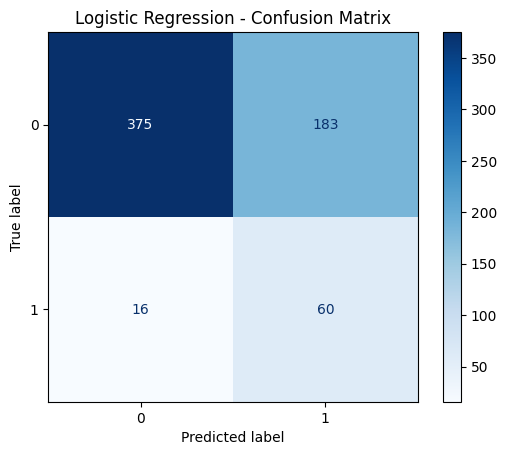


🔹 Training Random Forest...
ROC-AUC: 0.7700
F1-Score: 0.3373
              precision    recall  f1-score   support

         0.0       0.91      0.89      0.90       558
         1.0       0.31      0.37      0.34        76

    accuracy                           0.83       634
   macro avg       0.61      0.63      0.62       634
weighted avg       0.84      0.83      0.83       634



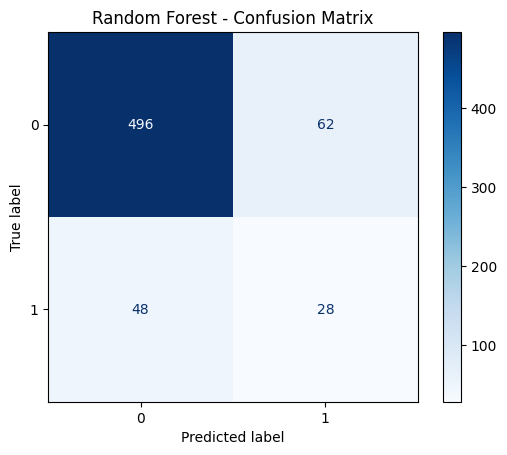


🔹 Training KNN...
ROC-AUC: 0.7434
F1-Score: 0.3590
              precision    recall  f1-score   support

         0.0       0.94      0.73      0.82       558
         1.0       0.25      0.64      0.36        76

    accuracy                           0.72       634
   macro avg       0.59      0.69      0.59       634
weighted avg       0.86      0.72      0.77       634



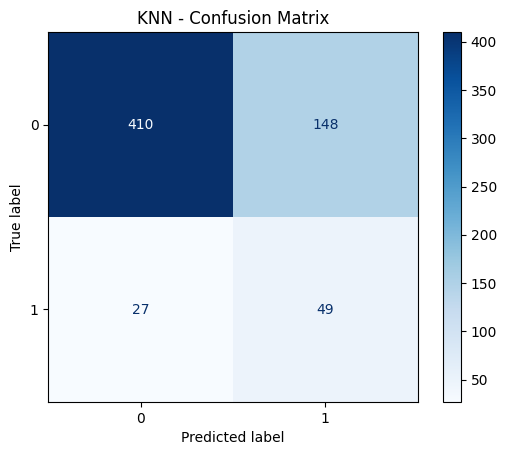


🔹 Training Naive Bayes...
ROC-AUC: 0.7725
F1-Score: 0.3448
              precision    recall  f1-score   support

         0.0       0.95      0.66      0.78       558
         1.0       0.23      0.72      0.34        76

    accuracy                           0.67       634
   macro avg       0.59      0.69      0.56       634
weighted avg       0.86      0.67      0.73       634



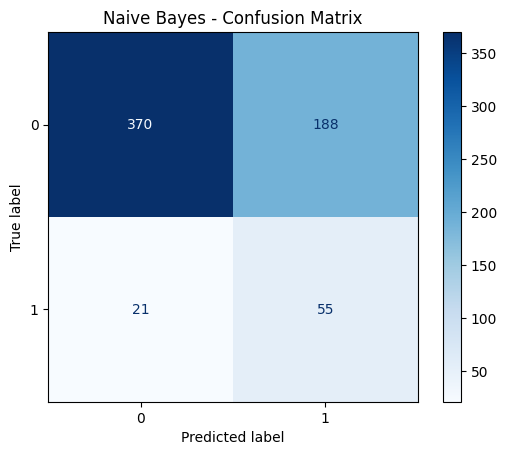


🔹 Training SVM...
ROC-AUC: 0.7883
F1-Score: 0.3785
              precision    recall  f1-score   support

         0.0       0.96      0.68      0.79       558
         1.0       0.25      0.79      0.38        76

    accuracy                           0.69       634
   macro avg       0.60      0.73      0.59       634
weighted avg       0.87      0.69      0.74       634



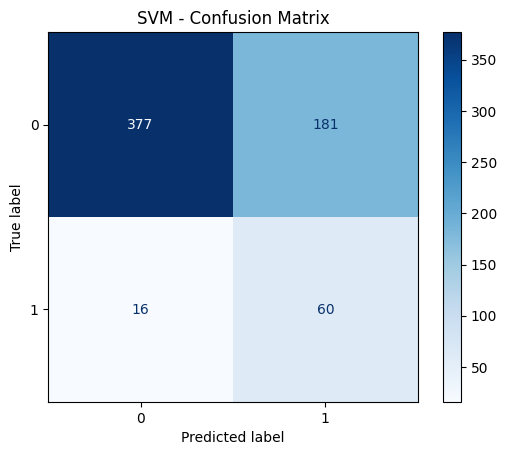


🔹 Training XGBoost...
ROC-AUC: 0.7632
F1-Score: 0.3185
              precision    recall  f1-score   support

         0.0       0.91      0.90      0.90       558
         1.0       0.31      0.33      0.32        76

    accuracy                           0.83       634
   macro avg       0.61      0.61      0.61       634
weighted avg       0.84      0.83      0.83       634



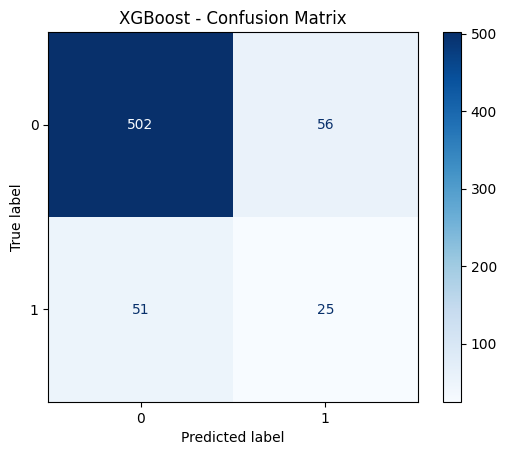


🏆 BEST MODEL: Logistic Regression with ROC-AUC: 0.7921


In [9]:
results = train_and_evaluate_model_SMOTE(models, X_train, y_train, X_test, y_test)

# Find best model
best_model_name = max(results.keys(), key=lambda x: results[x]['roc_auc'])
best_model = results[best_model_name]['model']
print(f"\n🏆 BEST MODEL: {best_model_name} with ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")

In [11]:
best_pipe = ImbPipeline([
    ('preprocess', preprocessor),
    ('over', over),
    ('under', under),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42,
        penalty='l2',
        C=0.1,
        class_weight='balanced'
    ))
])

best_pipe.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('over', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [14]:
new_patient = pd.DataFrame([{
    'Age': 21,
    'Gender': 2,
    'Height_cm': 160,
    'Weight_kg': 50,
    'Waist_cm': 100.5,
    'Hip_cm': 83.82,
    'Systolic_BP': 120,
    'Diastolic_BP': 80,
}])

prob = best_pipe.predict_proba(new_patient)[0]
print(f"Predicted Probability of No Diabetes: {prob[0]*100:.2f}%")
print(f"Predicted Probability of Diabetes: {prob[1]*100:.2f}%")




Predicted Probability of No Diabetes: 65.77%
Predicted Probability of Diabetes: 34.23%


In [15]:
import joblib

joblib.dump(best_pipe, "best_pipe.pkl")
print("✅ Saved best_pipe.pkl successfully!")

✅ Saved best_pipe.pkl successfully!
